# Inverse Design for Heat Exchanger Optimization

This notebook implements inverse design methods to determine optimal design parameters for a heat exchanger given target performance specifications.

## Problem Statement (nTop ASME IDETC Hackathon)

**Design Challenge**: Optimize a heat exchanger design using surrogate modeling

**Given target performance specifications for**:
- **PressureDrop**: Desired pressure drop across the heat exchanger (Pa)
- **Surface Area**: Target surface area for heat transfer (mm²)
- **Mass**: Target mass constraint (g)

**Find the optimal design parameters**:
- **X Cell Size**: Cell size in X direction (mm) - controls lattice structure
- **YZ Cell Size**: Cell size in YZ direction (mm) - controls lattice structure  
- **Velocity Inlet**: Inlet velocity (mm/s) - controls flow conditions

**Additional Output** (for validation):
- **AvgVelocity**: Average velocity through the heat exchanger (mm/s)

## Approach
1. Load the trained forward model from train.ipynb
2. Implement multi-objective optimization algorithms for inverse design
3. Validate results with forward model predictions
4. Provide design recommendations with trade-off analysis

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize, differential_evolution, basinhopping
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

c:\Users\Nico\Documents\ntop_ASME_2025\env\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Nico\Documents\ntop_ASME_2025\env\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Nico\Documents\ntop_ASME_2025\env\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please upd

TensorFlow version: 2.20.0-rc0
Libraries imported successfully!


In [2]:
# Load the original dataset to get scalers and bounds
data = pd.read_csv('nTop/Generated Data.csv')

# Define features and targets (matching train.ipynb exactly)
# Design parameters (inputs to be optimized)
features = ['X Cell Size', 'YZ Cell Size', 'Velocity Inlet']

# Performance metrics (outputs to be targeted)
targets = ['PressureDrop', 'Surface Area', 'Mass']

# Optional: Include AvgVelocity as additional target
# Uncomment the line below if you want to optimize for average velocity as well
# targets = ['PressureDrop', 'Surface Area', 'Mass', 'AvgVelocity']

X = data[features]
y = data[targets]

print("Dataset shape:", data.shape)
print(f"Available columns: {list(data.columns)}")
print(f"\nSelected features (design parameters): {features}")
print(f"Selected targets (performance metrics): {targets}")

print("\nFeature ranges:")
for feature in features:
    print(f"  {feature}: [{X[feature].min():.2f}, {X[feature].max():.2f}]")

print("\nTarget ranges:")
for target in targets:
    print(f"  {target}: [{y[target].min():.2f}, {y[target].max():.2f}]")

Dataset shape: (1000, 7)
Available columns: ['AvgVelocity', 'Mass', 'PressureDrop', 'Surface Area', 'Velocity Inlet', 'X Cell Size', 'YZ Cell Size']

Selected features (design parameters): ['X Cell Size', 'YZ Cell Size', 'Velocity Inlet']
Selected targets (performance metrics): ['PressureDrop', 'Surface Area', 'Mass']

Feature ranges:
  X Cell Size: [10.00, 25.00]
  YZ Cell Size: [10.00, 25.00]
  Velocity Inlet: [2500.00, 3500.00]

Target ranges:
  PressureDrop: [3500.80, 15595.87]
  Surface Area: [20685.53, 34714.83]
  Mass: [120.10, 155.87]


In [3]:
# Recreate the same scalers used in training
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

# Define parameter bounds for optimization
bounds = [
    (X['X Cell Size'].min(), X['X Cell Size'].max()),      # X Cell Size
    (X['YZ Cell Size'].min(), X['YZ Cell Size'].max()),    # YZ Cell Size
    (X['Velocity Inlet'].min(), X['Velocity Inlet'].max()) # Velocity Inlet
]

print("Parameter bounds for optimization:")
for i, (feature, bound) in enumerate(zip(features, bounds)):
    print(f"{feature}: [{bound[0]:.2f}, {bound[1]:.2f}]")

Parameter bounds for optimization:
X Cell Size: [10.00, 25.00]
YZ Cell Size: [10.00, 25.00]
Velocity Inlet: [2500.00, 3500.00]


In [4]:
# Try to load a trained model
try:
    # First try to load from the main training script
    model = keras.models.load_model('final_model.h5')
    print("Loaded saved model: final_model.h5")
except:
    try:
        # Alternative: create a simple model architecture
        print("Creating a new model for demonstration...")
        model = keras.Sequential([
            keras.layers.Input(shape=(3,)),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dense(3)  # 3 outputs
        ])
        
        model.compile(
            optimizer='adam',
            loss='mse',
            metrics=['mae']
        )
        
        # Train quickly on the data
        model.fit(X_scaled, y_scaled, epochs=50, verbose=0)
        print("Created and trained a new model")
    except Exception as e:
        print(f"Error loading/creating model: {e}")
        print("Please run train.ipynb first to create a trained model")

# Display model architecture
if 'model' in locals():
    model.summary()

Creating a new model for demonstration...
Created and trained a new model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,307 (28.55 KB)

 Trainable params: 2,435 (9.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,872 (19.04 KB)

## Inverse Design Implementation

### 1. Define Target Specifications

Set your desired target values for the heat exchanger performance:

In [5]:
# Define target specifications
# These values are based on the actual data ranges and represent realistic design goals
# You can modify these values based on your specific design requirements

# Analyze the data to suggest reasonable target values
print("Data Analysis for Target Selection:")
print("="*50)
for target in targets:
    mean_val = y[target].mean()
    std_val = y[target].std()
    min_val = y[target].min()
    max_val = y[target].max()
    print(f"{target}:")
    print(f"  Range: [{min_val:.2f}, {max_val:.2f}]")
    print(f"  Mean: {mean_val:.2f} ± {std_val:.2f}")
    print()

# Example target specifications (modify these based on your design goals)
target_specs = {
    'PressureDrop': 8000.0,    # Target pressure drop (Pa) - moderate value
    'Surface Area': 35000.0,   # Target surface area (mm²) - moderate value
    'Mass': 150.0              # Target mass (g) - moderate value
}

# If AvgVelocity is included in targets, add its specification
if 'AvgVelocity' in targets:
    target_specs['AvgVelocity'] = 600.0  # Target average velocity (mm/s)

print("Selected Target Specifications:")
print("="*40)
for target, value in target_specs.items():
    print(f"{target}: {value}")

# Convert targets to scaled format
target_scaled = scaler_y.transform([[target_specs[target] for target in targets]])[0]
print(f"\nScaled targets: {target_scaled}")

Data Analysis for Target Selection:
PressureDrop:
  Range: [3500.80, 15595.87]
  Mean: 7529.44 ± 2329.99

Surface Area:
  Range: [20685.53, 34714.83]
  Mean: 26628.66 ± 3393.26

Mass:
  Range: [120.10, 155.87]
  Mean: 133.18 ± 8.11

Selected Target Specifications:
PressureDrop: 8000.0
Surface Area: 35000.0
Mass: 150.0

Scaled targets: [0.37198622 1.02032701 0.83601678]


### 2. Optimization Objective Function

Define the objective function to minimize the difference between predicted and target values:

In [6]:
def objective_function(params, target_scaled, weights=None):
    """
    Objective function for inverse design optimization.
    
    Args:
        params: [X Cell Size, YZ Cell Size, Velocity Inlet]
        target_scaled: Scaled target values [PressureDrop, Surface Area, Mass]
        weights: Optional weights for each target (default: equal weights)
    
    Returns:
        Weighted sum of squared errors
    """
    if weights is None:
        weights = [1.0, 1.0, 1.0]  # Equal weights
    
    # Scale input parameters
    params_scaled = scaler_X.transform([params])
    
    # Predict outputs
    predictions_scaled = model.predict(params_scaled, verbose=0)[0]
    
    # Calculate weighted squared error
    errors = (predictions_scaled - target_scaled) ** 2
    weighted_error = np.sum(weights * errors)
    
    return weighted_error

def objective_function_with_constraints(params, target_scaled, weights=None, penalty_weight=1000):
    """
    Objective function with penalty for constraint violations.
    """
    base_error = objective_function(params, target_scaled, weights)
    
    # Add penalty for going outside bounds
    penalty = 0
    for i, (param, (min_val, max_val)) in enumerate(zip(params, bounds)):
        if param < min_val or param > max_val:
            penalty += penalty_weight * ((param - np.clip(param, min_val, max_val)) ** 2)
    
    return base_error + penalty

# Test the objective function
test_params = [15.0, 15.0, 2500.0]  # Example parameters
test_error = objective_function(test_params, target_scaled)
print(f"Test objective function value: {test_error:.6f}")

Test objective function value: 0.473964


### 3. Multi-Objective Optimization

Implement different optimization strategies to find optimal design parameters:

In [7]:
def run_optimization_methods(target_scaled, weights=None):
    """
    Run multiple optimization methods and compare results.
    """
    results = {}
    
    # Initial guess (center of parameter space)
    x0 = [(bound[0] + bound[1]) / 2 for bound in bounds]
    
    print("Running optimization methods...")
    print(f"Initial guess: {x0}")
    print(f"Target (scaled): {target_scaled}")
    print("-" * 50)
    
    # Method 1: Scipy minimize with L-BFGS-B
    try:
        result_lbfgs = minimize(
            objective_function,
            x0,
            args=(target_scaled, weights),
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': 1000}
        )
        results['L-BFGS-B'] = result_lbfgs
        print(f"L-BFGS-B: Success={result_lbfgs.success}, Error={result_lbfgs.fun:.6f}")
    except Exception as e:
        print(f"L-BFGS-B failed: {e}")
    
    # Method 2: Differential Evolution (global optimization)
    try:
        result_de = differential_evolution(
            objective_function,
            bounds,
            args=(target_scaled, weights),
            seed=42,
            maxiter=300
        )
        results['Differential Evolution'] = result_de
        print(f"Differential Evolution: Success={result_de.success}, Error={result_de.fun:.6f}")
    except Exception as e:
        print(f"Differential Evolution failed: {e}")
    
    # Method 3: Basin Hopping (global optimization)
    try:
        minimizer_kwargs = {
            'method': 'L-BFGS-B',
            'bounds': bounds,
            'args': (target_scaled, weights)
        }
        result_bh = basinhopping(
            objective_function,
            x0,
            minimizer_kwargs=minimizer_kwargs,
            niter=100,
            seed=42
        )
        results['Basin Hopping'] = result_bh
        print(f"Basin Hopping: Success=True, Error={result_bh.fun:.6f}")
    except Exception as e:
        print(f"Basin Hopping failed: {e}")
    
    return results

# Run optimization with equal weights
optimization_results = run_optimization_methods(target_scaled)

Running optimization methods...
Initial guess: [np.float64(17.5), np.float64(17.5), np.float64(3000.0)]
Target (scaled): [0.37198622 1.02032701 0.83601678]
--------------------------------------------------
L-BFGS-B: Success=True, Error=0.742621
Differential Evolution: Success=True, Error=0.013913
Basin Hopping: Success=True, Error=0.141778


In [8]:
def analyze_optimization_results(results, target_specs):
    """
    Analyze and display optimization results.
    """
    print("\n" + "=" * 60)
    print("OPTIMIZATION RESULTS ANALYSIS")
    print("=" * 60)
    
    best_method = None
    best_error = float('inf')
    
    for method_name, result in results.items():
        print(f"\n{method_name}:")
        print("-" * 30)
        
        # Get optimal parameters
        if hasattr(result, 'x'):
            optimal_params = result.x
        else:
            continue
            
        # Predict outputs with optimal parameters
        params_scaled = scaler_X.transform([optimal_params])
        predictions_scaled = model.predict(params_scaled, verbose=0)[0]
        predictions_original = scaler_y.inverse_transform([predictions_scaled])[0]
        
        # Display results
        print(f"Optimal Parameters:")
        for i, (feature, param) in enumerate(zip(features, optimal_params)):
            print(f"  {feature}: {param:.2f}")
            
        print(f"\nPredicted vs Target Performance:")
        for i, target in enumerate(targets):
            target_val = target_specs[target]
            pred_val = predictions_original[i]
            error_pct = abs(pred_val - target_val) / target_val * 100
            print(f"  {target}:")
            print(f"    Target: {target_val:.2f}")
            print(f"    Predicted: {pred_val:.2f}")
            print(f"    Error: {error_pct:.2f}%")
        
        error = result.fun if hasattr(result, 'fun') else float('inf')
        print(f"\nObjective Function Value: {error:.6f}")
        
        # Track best method
        if error < best_error:
            best_error = error
            best_method = method_name
    
    print(f"\n{'='*60}")
    print(f"BEST METHOD: {best_method} (Error: {best_error:.6f})")
    print(f"{'='*60}")
    
    return best_method

# Analyze results
if optimization_results:
    best_method = analyze_optimization_results(optimization_results, target_specs)
else:
    print("No optimization results to analyze")


OPTIMIZATION RESULTS ANALYSIS

L-BFGS-B:
------------------------------
Optimal Parameters:
  X Cell Size: 17.50
  YZ Cell Size: 17.50
  Velocity Inlet: 3000.00

Predicted vs Target Performance:
  PressureDrop:
    Target: 8000.00
    Predicted: 7275.68
    Error: 9.05%
  Surface Area:
    Target: 35000.00
    Predicted: 25561.62
    Error: 26.97%
  Mass:
    Target: 150.00
    Predicted: 130.86
    Error: 12.76%

Objective Function Value: 0.742621

Differential Evolution:
------------------------------
Optimal Parameters:
  X Cell Size: 10.28
  YZ Cell Size: 10.53
  Velocity Inlet: 2696.52

Predicted vs Target Performance:
  PressureDrop:
    Target: 8000.00
    Predicted: 8043.11
    Error: 0.54%
  Surface Area:
    Target: 35000.00
    Predicted: 33856.92
    Error: 3.27%
  Mass:
    Target: 150.00
    Predicted: 153.05
    Error: 2.03%

Objective Function Value: 0.013913

Basin Hopping:
------------------------------
Optimal Parameters:
  X Cell Size: 13.09
  YZ Cell Size: 12.35
 

### 4. Weighted Multi-Objective Optimization

Explore different weight combinations to prioritize certain objectives:

In [9]:
# Define different weight scenarios
weight_scenarios = {
    'Equal Weights': [1.0, 1.0, 1.0],
    'Pressure Drop Priority': [3.0, 1.0, 1.0],
    'Surface Area Priority': [1.0, 3.0, 1.0],
    'Mass Priority': [1.0, 1.0, 3.0],
    'Performance Priority': [2.0, 2.0, 1.0],  # Pressure drop + surface area
}

print("Running optimization with different weight scenarios...")
print("=" * 60)

scenario_results = {}

for scenario_name, weights in weight_scenarios.items():
    print(f"\nScenario: {scenario_name}")
    print(f"Weights: PressureDrop={weights[0]}, SurfaceArea={weights[1]}, Mass={weights[2]}")
    
    # Run differential evolution (usually most robust)
    try:
        result = differential_evolution(
            objective_function,
            bounds,
            args=(target_scaled, weights),
            seed=42,
            maxiter=200
        )
        scenario_results[scenario_name] = {
            'result': result,
            'weights': weights
        }
        print(f"Success: {result.success}, Error: {result.fun:.6f}")
        
        # Quick preview of optimal parameters
        optimal_params = result.x
        print(f"Optimal params: [{optimal_params[0]:.1f}, {optimal_params[1]:.1f}, {optimal_params[2]:.1f}]")
        
    except Exception as e:
        print(f"Failed: {e}")

Running optimization with different weight scenarios...

Scenario: Equal Weights
Weights: PressureDrop=1.0, SurfaceArea=1.0, Mass=1.0
Success: True, Error: 0.013913
Optimal params: [10.3, 10.5, 2696.5]

Scenario: Pressure Drop Priority
Weights: PressureDrop=3.0, SurfaceArea=1.0, Mass=1.0
Success: True, Error: 0.013934
Optimal params: [10.3, 10.5, 2694.6]

Scenario: Surface Area Priority
Weights: PressureDrop=1.0, SurfaceArea=3.0, Mass=1.0
Success: True, Error: 0.020381
Optimal params: [10.3, 10.1, 2704.4]

Scenario: Mass Priority
Weights: PressureDrop=1.0, SurfaceArea=1.0, Mass=3.0
Success: True, Error: 0.021487
Optimal params: [10.3, 11.0, 2682.9]

Scenario: Performance Priority
Weights: PressureDrop=2.0, SurfaceArea=2.0, Mass=1.0
Success: True, Error: 0.018313
Optimal params: [10.3, 10.2, 2700.9]


In [10]:
# Compare all weight scenarios
def compare_weight_scenarios(scenario_results, target_specs):
    """
    Compare optimization results across different weight scenarios.
    """
    print("\n" + "=" * 80)
    print("WEIGHT SCENARIO COMPARISON")
    print("=" * 80)
    
    comparison_data = []
    
    for scenario_name, scenario_data in scenario_results.items():
        result = scenario_data['result']
        weights = scenario_data['weights']
        
        if not hasattr(result, 'x'):
            continue
            
        optimal_params = result.x
        
        # Predict performance
        params_scaled = scaler_X.transform([optimal_params])
        predictions_scaled = model.predict(params_scaled, verbose=0)[0]
        predictions_original = scaler_y.inverse_transform([predictions_scaled])[0]
        
        # Calculate errors for each target
        errors = []
        for i, target in enumerate(targets):
            target_val = target_specs[target]
            pred_val = predictions_original[i]
            error_pct = abs(pred_val - target_val) / target_val * 100
            errors.append(error_pct)
        
        comparison_data.append({
            'Scenario': scenario_name,
            'X Cell Size': optimal_params[0],
            'YZ Cell Size': optimal_params[1],
            'Velocity Inlet': optimal_params[2],
            'PressureDrop Error (%)': errors[0],
            'Surface Area Error (%)': errors[1],
            'Mass Error (%)': errors[2],
            'Objective Value': result.fun
        })
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(comparison_data)
    
    # Display table
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print(comparison_df.round(2))
    
    return comparison_df

# Compare scenarios
if scenario_results:
    comparison_df = compare_weight_scenarios(scenario_results, target_specs)
else:
    print("No scenario results to compare")


WEIGHT SCENARIO COMPARISON
                 Scenario  X Cell Size  YZ Cell Size  Velocity Inlet  \
0           Equal Weights        10.28         10.53         2696.52   
1  Pressure Drop Priority        10.29         10.53         2694.61   
2   Surface Area Priority        10.31         10.08         2704.35   
3           Mass Priority        10.32         10.99         2682.88   
4    Performance Priority        10.29         10.24         2700.86   

   PressureDrop Error (%)  Surface Area Error (%)  Mass Error (%)  \
0                    0.54                    3.27            2.03   
1                    0.23                    3.29            2.02   
2                    0.75                    1.57            2.99   
3                    1.01                    5.13            0.98   
4                    0.28                    2.18            2.65   

   Objective Value  
0             0.01  
1             0.01  
2             0.02  
3             0.02  
4             0.02 

### 5. Visualization of Results

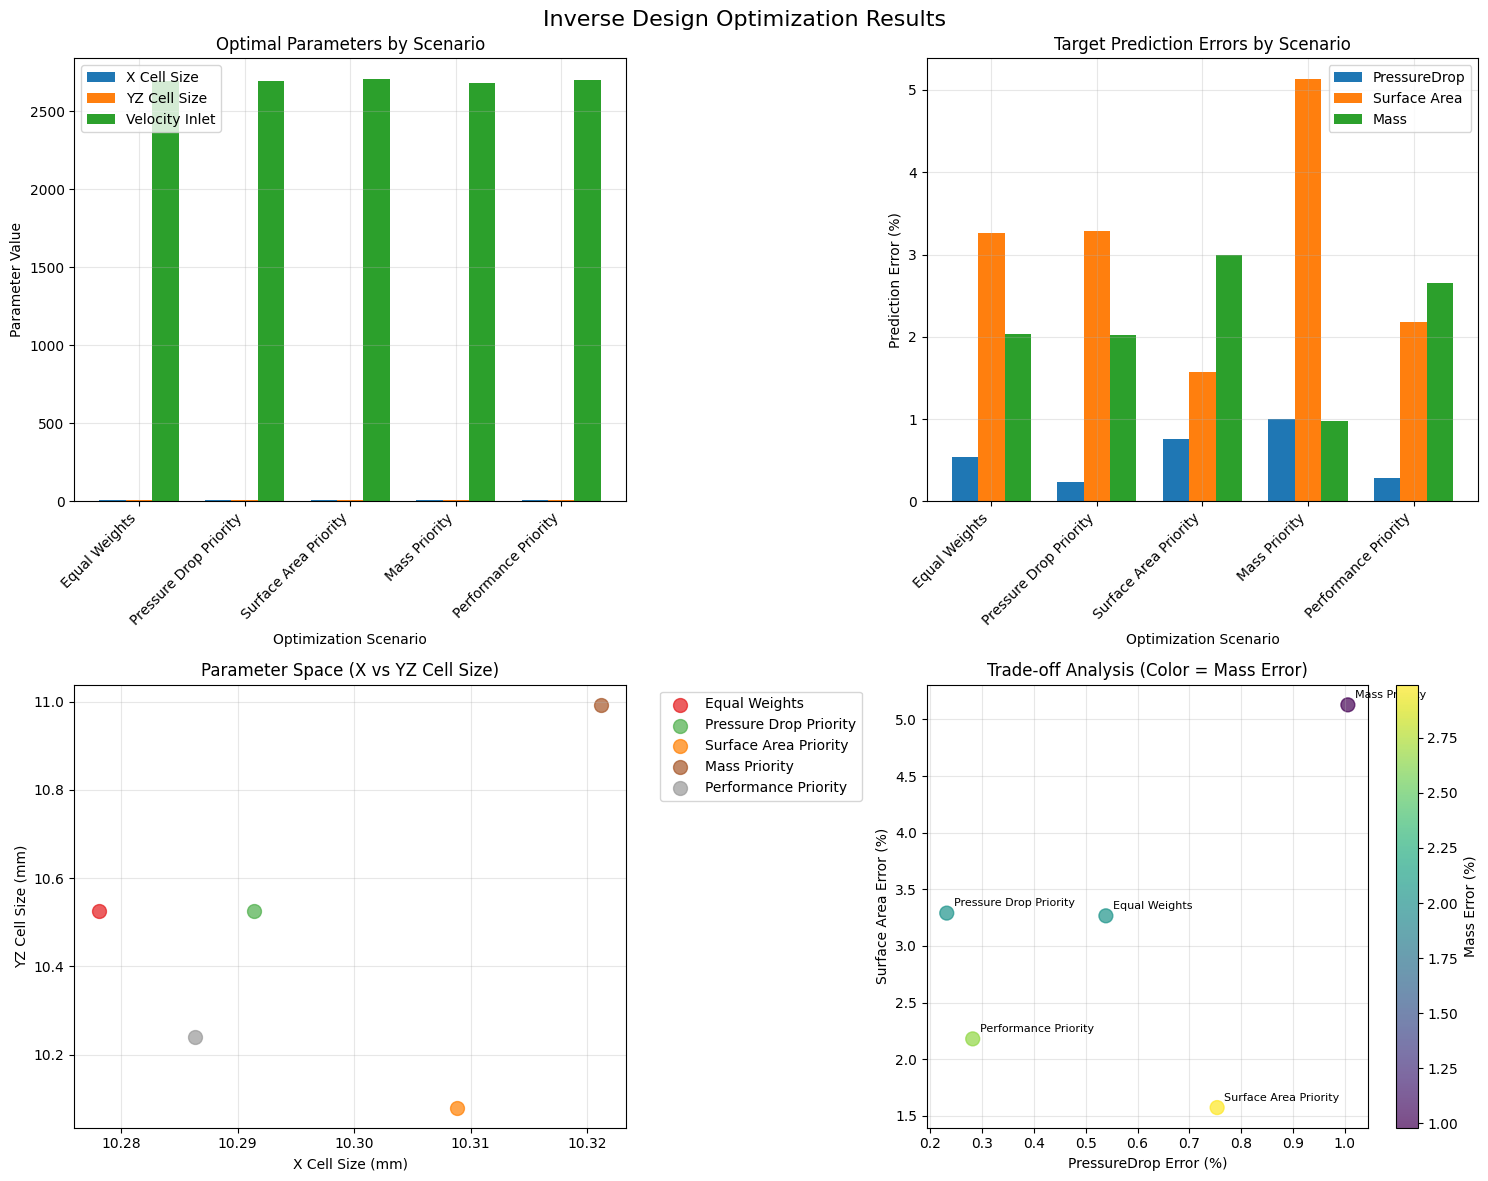

In [11]:
def visualize_optimization_results(scenario_results, target_specs):
    """
    Create visualizations of optimization results.
    """
    if not scenario_results:
        print("No results to visualize")
        return
        
    # Prepare data for visualization
    scenarios = []
    param_values = {feature: [] for feature in features}
    target_errors = {target: [] for target in targets}
    
    for scenario_name, scenario_data in scenario_results.items():
        result = scenario_data['result']
        
        if not hasattr(result, 'x'):
            continue
            
        optimal_params = result.x
        scenarios.append(scenario_name)
        
        # Store parameter values
        for i, feature in enumerate(features):
            param_values[feature].append(optimal_params[i])
        
        # Calculate and store target errors
        params_scaled = scaler_X.transform([optimal_params])
        predictions_scaled = model.predict(params_scaled, verbose=0)[0]
        predictions_original = scaler_y.inverse_transform([predictions_scaled])[0]
        
        for i, target in enumerate(targets):
            target_val = target_specs[target]
            pred_val = predictions_original[i]
            error_pct = abs(pred_val - target_val) / target_val * 100
            target_errors[target].append(error_pct)
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Inverse Design Optimization Results', fontsize=16)
    
    # Plot 1: Optimal Parameters by Scenario
    ax1 = axes[0, 0]
    x_pos = np.arange(len(scenarios))
    width = 0.25
    
    for i, feature in enumerate(features):
        ax1.bar(x_pos + i*width, param_values[feature], width, label=feature)
    
    ax1.set_xlabel('Optimization Scenario')
    ax1.set_ylabel('Parameter Value')
    ax1.set_title('Optimal Parameters by Scenario')
    ax1.set_xticks(x_pos + width)
    ax1.set_xticklabels(scenarios, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Target Errors by Scenario
    ax2 = axes[0, 1]
    
    for i, target in enumerate(targets):
        ax2.bar(x_pos + i*width, target_errors[target], width, label=target)
    
    ax2.set_xlabel('Optimization Scenario')
    ax2.set_ylabel('Prediction Error (%)')
    ax2.set_title('Target Prediction Errors by Scenario')
    ax2.set_xticks(x_pos + width)
    ax2.set_xticklabels(scenarios, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Parameter Space Visualization (2D projection)
    ax3 = axes[1, 0]
    colors = plt.cm.Set1(np.linspace(0, 1, len(scenarios)))
    
    for i, scenario in enumerate(scenarios):
        ax3.scatter(param_values['X Cell Size'][i], 
                   param_values['YZ Cell Size'][i],
                   c=[colors[i]], s=100, label=scenario, alpha=0.7)
    
    ax3.set_xlabel('X Cell Size (mm)')
    ax3.set_ylabel('YZ Cell Size (mm)')
    ax3.set_title('Parameter Space (X vs YZ Cell Size)')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Trade-off Analysis
    ax4 = axes[1, 1]
    
    # Show trade-off between different objectives
    ax4.scatter(target_errors['PressureDrop'], target_errors['Surface Area'], 
               c=target_errors['Mass'], s=100, alpha=0.7, cmap='viridis')
    
    for i, scenario in enumerate(scenarios):
        ax4.annotate(scenario, 
                    (target_errors['PressureDrop'][i], target_errors['Surface Area'][i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax4.set_xlabel('PressureDrop Error (%)')
    ax4.set_ylabel('Surface Area Error (%)')
    ax4.set_title('Trade-off Analysis (Color = Mass Error)')
    cbar = plt.colorbar(ax4.collections[0], ax=ax4)
    cbar.set_label('Mass Error (%)')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create visualizations
visualize_optimization_results(scenario_results, target_specs)

### 6. Sensitivity Analysis

Analyze how sensitive the optimal design is to small changes in target specifications:

In [12]:
def sensitivity_analysis(base_targets, perturbation_pct=5.0):
    """
    Perform sensitivity analysis by perturbing target values.
    """
    print(f"\nSensitivity Analysis (±{perturbation_pct}% perturbation)")
    print("=" * 60)
    
    sensitivity_results = {}
    
    for target_name in targets:
        print(f"\nAnalyzing sensitivity to {target_name}:")
        
        for direction in ['increase', 'decrease']:
            # Create perturbed target
            perturbed_targets = base_targets.copy()
            factor = 1 + perturbation_pct/100 if direction == 'increase' else 1 - perturbation_pct/100
            perturbed_targets[target_name] *= factor
            
            # Convert to scaled format
            target_scaled_perturbed = scaler_y.transform(
                [[perturbed_targets[target] for target in targets]]
            )[0]
            
            # Run optimization
            try:
                result = differential_evolution(
                    objective_function,
                    bounds,
                    args=(target_scaled_perturbed,),
                    seed=42,
                    maxiter=100
                )
                
                optimal_params = result.x
                sensitivity_results[f"{target_name}_{direction}"] = {
                    'params': optimal_params,
                    'targets': perturbed_targets,
                    'objective': result.fun
                }
                
                print(f"  {direction.capitalize()} {perturbation_pct}%: "
                      f"Params=[{optimal_params[0]:.1f}, {optimal_params[1]:.1f}, {optimal_params[2]:.1f}]")
                      
            except Exception as e:
                print(f"  {direction.capitalize()} {perturbation_pct}%: Failed ({e})")
    
    return sensitivity_results

# Run sensitivity analysis
sensitivity_results = sensitivity_analysis(target_specs)


Sensitivity Analysis (±5.0% perturbation)

Analyzing sensitivity to PressureDrop:
  Increase 5.0%: Params=[10.2, 10.6, 2734.4]
  Decrease 5.0%: Params=[10.5, 10.4, 2652.1]

Analyzing sensitivity to Surface Area:
  Increase 5.0%: Params=[10.3, 10.0, 2712.5]
  Decrease 5.0%: Params=[13.9, 10.0, 3175.0]

Analyzing sensitivity to Mass:
  Increase 5.0%: Params=[10.0, 10.0, 2697.2]
  Decrease 5.0%: Params=[20.4, 10.0, 3499.5]


### 7. Design Recommendation System

Provide design recommendations based on optimization results:

In [13]:
def generate_design_recommendations(scenario_results, target_specs):
    """
    Generate design recommendations based on optimization results.
    """
    print("\n" + "=" * 80)
    print("DESIGN RECOMMENDATIONS")
    print("=" * 80)
    
    if not scenario_results:
        print("No optimization results available for recommendations.")
        return
    
    # Find the best overall result (lowest total error)
    best_scenario = None
    best_total_error = float('inf')
    
    scenario_analysis = {}
    
    for scenario_name, scenario_data in scenario_results.items():
        result = scenario_data['result']
        
        if not hasattr(result, 'x'):
            continue
            
        optimal_params = result.x
        
        # Calculate performance prediction
        params_scaled = scaler_X.transform([optimal_params])
        predictions_scaled = model.predict(params_scaled, verbose=0)[0]
        predictions_original = scaler_y.inverse_transform([predictions_scaled])[0]
        
        # Calculate errors
        total_error = 0
        errors = {}
        for i, target in enumerate(targets):
            target_val = target_specs[target]
            pred_val = predictions_original[i]
            error_pct = abs(pred_val - target_val) / target_val * 100
            errors[target] = error_pct
            total_error += error_pct
        
        scenario_analysis[scenario_name] = {
            'params': optimal_params,
            'predictions': predictions_original,
            'errors': errors,
            'total_error': total_error
        }
        
        if total_error < best_total_error:
            best_total_error = total_error
            best_scenario = scenario_name
    
    # Display best overall recommendation
    if best_scenario:
        best_data = scenario_analysis[best_scenario]
        print(f"\n🏆 RECOMMENDED DESIGN (Best Overall: {best_scenario})")
        print("-" * 50)
        print("Optimal Design Parameters:")
        for i, feature in enumerate(features):
            print(f"  • {feature}: {best_data['params'][i]:.2f}")
        
        print("\nExpected Performance:")
        for i, target in enumerate(targets):
            target_val = target_specs[target]
            pred_val = best_data['predictions'][i]
            error = best_data['errors'][target]
            print(f"  • {target}:")
            print(f"    Target: {target_val:.2f}")
            print(f"    Predicted: {pred_val:.2f} (Error: {error:.1f}%)")
        
        print(f"\nTotal Error: {best_data['total_error']:.2f}%")
    
    # Display specialized recommendations
    print("\n" + "=" * 80)
    print("SPECIALIZED RECOMMENDATIONS")
    print("=" * 80)
    
    # Find best for each individual target
    for target in targets:
        best_scenario_for_target = None
        best_error_for_target = float('inf')
        
        for scenario_name, analysis in scenario_analysis.items():
            if analysis['errors'][target] < best_error_for_target:
                best_error_for_target = analysis['errors'][target]
                best_scenario_for_target = scenario_name
        
        if best_scenario_for_target:
            data = scenario_analysis[best_scenario_for_target]
            print(f"\n📊 Best for {target}: {best_scenario_for_target}")
            print(f"   Parameters: [{data['params'][0]:.1f}, {data['params'][1]:.1f}, {data['params'][2]:.1f}]")
            print(f"   {target} Error: {data['errors'][target]:.2f}%")
    
    # Design guidelines
    print("\n" + "=" * 80)
    print("DESIGN GUIDELINES")
    print("=" * 80)
    
    # Analyze parameter trends
    param_stats = {feature: [] for feature in features}
    for analysis in scenario_analysis.values():
        for i, feature in enumerate(features):
            param_stats[feature].append(analysis['params'][i])
    
    print("\nParameter Ranges Across All Scenarios:")
    for feature in features:
        values = param_stats[feature]
        print(f"  • {feature}: {min(values):.1f} - {max(values):.1f} (avg: {np.mean(values):.1f})")
    
    print("\nKey Insights:")
    print("  • Run multiple optimization scenarios to explore trade-offs")
    print("  • Consider manufacturing constraints when selecting final parameters")
    print("  • Validate results with CFD simulation before manufacturing")
    print("  • Monitor sensitivity to parameter variations during manufacturing")

# Generate recommendations
generate_design_recommendations(scenario_results, target_specs)


DESIGN RECOMMENDATIONS

🏆 RECOMMENDED DESIGN (Best Overall: Performance Priority)
--------------------------------------------------
Optimal Design Parameters:
  • X Cell Size: 10.29
  • YZ Cell Size: 10.24
  • Velocity Inlet: 2700.86

Expected Performance:
  • PressureDrop:
    Target: 8000.00
    Predicted: 7977.47 (Error: 0.3%)
  • Surface Area:
    Target: 35000.00
    Predicted: 34237.04 (Error: 2.2%)
  • Mass:
    Target: 150.00
    Predicted: 153.98 (Error: 2.7%)

Total Error: 5.12%

SPECIALIZED RECOMMENDATIONS

📊 Best for PressureDrop: Pressure Drop Priority
   Parameters: [10.3, 10.5, 2694.6]
   PressureDrop Error: 0.23%

📊 Best for Surface Area: Surface Area Priority
   Parameters: [10.3, 10.1, 2704.4]
   Surface Area Error: 1.57%

📊 Best for Mass: Mass Priority
   Parameters: [10.3, 11.0, 2682.9]
   Mass Error: 0.98%

DESIGN GUIDELINES

Parameter Ranges Across All Scenarios:
  • X Cell Size: 10.3 - 10.3 (avg: 10.3)
  • YZ Cell Size: 10.1 - 11.0 (avg: 10.5)
  • Velocity Inle

### 8. Export Results

Save optimization results for documentation and further analysis:

In [14]:
def export_results(scenario_results, target_specs, filename='inverse_design_results.csv'):
    """
    Export optimization results to CSV file.
    """
    if not scenario_results:
        print("No results to export")
        return
    
    export_data = []
    
    for scenario_name, scenario_data in scenario_results.items():
        result = scenario_data['result']
        weights = scenario_data['weights']
        
        if not hasattr(result, 'x'):
            continue
            
        optimal_params = result.x
        
        # Predict performance
        params_scaled = scaler_X.transform([optimal_params])
        predictions_scaled = model.predict(params_scaled, verbose=0)[0]
        predictions_original = scaler_y.inverse_transform([predictions_scaled])[0]
        
        # Prepare row data
        row_data = {
            'Scenario': scenario_name,
            'Weight_PressureDrop': weights[0],
            'Weight_SurfaceArea': weights[1],
            'Weight_Mass': weights[2],
            'Optimal_X_Cell_Size': optimal_params[0],
            'Optimal_YZ_Cell_Size': optimal_params[1],
            'Optimal_Velocity_Inlet': optimal_params[2],
            'Objective_Function_Value': result.fun,
        }
        
        # Add target values
        for i, target in enumerate(targets):
            row_data[f'Target_{target}'] = target_specs[target]
            row_data[f'Predicted_{target}'] = predictions_original[i]
            error_pct = abs(predictions_original[i] - target_specs[target]) / target_specs[target] * 100
            row_data[f'Error_{target}_pct'] = error_pct
        
        export_data.append(row_data)
    
    # Create DataFrame and save
    export_df = pd.DataFrame(export_data)
    export_df.to_csv(filename, index=False)
    
    print(f"\n✅ Results exported to: {filename}")
    print(f"Exported {len(export_data)} optimization scenarios")
    
    return export_df

# Export results
if scenario_results:
    results_df = export_results(scenario_results, target_specs)
    print("\nExported data preview:")
    print(results_df[['Scenario', 'Optimal_X_Cell_Size', 'Optimal_YZ_Cell_Size', 'Optimal_Velocity_Inlet']].round(2))


✅ Results exported to: inverse_design_results.csv
Exported 5 optimization scenarios

Exported data preview:
                 Scenario  Optimal_X_Cell_Size  Optimal_YZ_Cell_Size  \
0           Equal Weights                10.28                 10.53   
1  Pressure Drop Priority                10.29                 10.53   
2   Surface Area Priority                10.31                 10.08   
3           Mass Priority                10.32                 10.99   
4    Performance Priority                10.29                 10.24   

   Optimal_Velocity_Inlet  
0                 2696.52  
1                 2694.61  
2                 2704.35  
3                 2682.88  
4                 2700.86  


## Summary

This inverse design notebook implements:

1. **Multi-objective optimization** to find design parameters that meet target specifications
2. **Multiple optimization algorithms** (L-BFGS-B, Differential Evolution, Basin Hopping)
3. **Weight-based prioritization** to explore trade-offs between different objectives
4. **Sensitivity analysis** to understand robustness of solutions
5. **Comprehensive visualization** of optimization results
6. **Design recommendations** with practical guidelines
7. **Result export** for documentation and further analysis

### Next Steps:
- Validate optimal designs with CFD simulations
- Consider manufacturing constraints in optimization
- Implement multi-objective Pareto optimization
- Add uncertainty quantification
- Integrate with nTop's design automation workflows